In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL.ImImagePlugin import number
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay, classification_report)

sns.set_style("whitegrid")

In [2]:
penguins = sns.load_dataset("penguins").dropna()

In [3]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [4]:
print("\nData types:\n", penguins.dtypes)

print("\nSpecies distribution:\n", penguins["species"].value_counts())


Data types:
 species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object

Species distribution:
 species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


In [5]:
penguins.select_dtypes(include='number')

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0
...,...,...,...,...
338,47.2,13.7,214.0,4925.0
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


In [6]:
penguins.select_dtypes(include='string')

,species,island,sex
0,Adelie,Torgersen,Male
1,Adelie,Torgersen,Female
2,Adelie,Torgersen,Female
4,Adelie,Torgersen,Female
5,Adelie,Torgersen,Male
...,...,...,...
338,Gentoo,Biscoe,Female
340,Gentoo,Biscoe,Female
341,Gentoo,Biscoe,Male
342,Gentoo,Biscoe,Female


In [7]:
le = LabelEncoder()
y = le.fit_transform(penguins["species"])
X=penguins.drop("species", axis=1)
X = pd.get_dummies(X, columns=["island", "sex"], drop_first=True)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_reg = LogisticRegression(
    solver='lbfgs',
    max_iter=10000,
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Logistic Regression Accuracy: 0.9851

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



The logistic regression model performs very well on this dataset, typically achieving accuracy above 95%. This indicates that the species of penguins are highly separable based on the provided features.

Easiest species to classify:
Gentoo is usually the easiest to classify. This is because it has distinctly larger body mass and flipper length compared to the other species, making it well-separated in feature space.

Hardest species to classify:
Adelie and Chinstrap are more difficult to distinguish from each other. Their physical measurements (bill length, bill depth, etc.) overlap more, leading to occasional misclassifications.

Why this happens:
Logistic regression creates linear decision boundaries.
Gentoo forms a clearly separable cluster → high precision & recall.
Adelie and Chinstrap overlap → more confusion between them.

TASK2

In [10]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

y_pred_nb = gnb.predict(X_test_scaled)

print(f"Gaussian Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

Gaussian Naive Bayes Accuracy: 0.7761

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      0.48      0.65        29
   Chinstrap       0.58      1.00      0.74        14
      Gentoo       0.83      1.00      0.91        24

    accuracy                           0.78        67
   macro avg       0.80      0.83      0.76        67
weighted avg       0.85      0.78      0.76        67



In [11]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

y_pred_svm_lin = svm_linear.predict(X_test_scaled)
print(f"SVM (Linear) Accuracy: {accuracy_score(y_test, y_pred_svm_lin):.4f}")

svm_rbf = SVC(kernel='rbf', C=1.0, random_state=42, probability=True)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)
print(f"SVM (RBF) Accuracy: {accuracy_score(y_test, y_pred_svm_rbf):.4f}")


SVM (Linear) Accuracy: 0.9851
SVM (RBF) Accuracy: 0.9851


In [12]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")


Decision Tree Accuracy: 0.9552


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")


Random Forest Accuracy: 1.0000


In [14]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "GaussianNB": GaussianNB(),
    "SVC (Linear)": SVC(kernel="linear", probability=True),
    "SVC (RBF)": SVC(kernel="rbf", probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)  # ✅ inside loop

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    fitted_models[name] = model
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
4,Random Forest,1.000000,1.000000,1.000000,1.000000
2,SVC (RBF),0.985075,0.986070,0.985075,0.985201
1,SVC (Linear),0.985075,0.986070,0.985075,0.985201
3,Decision Tree,0.955224,0.957214,0.955224,0.955212
0,GaussianNB,0.776119,0.851175,0.776119,0.760229


Model Comparison and Insights

The results show that Random Forest and SVC with RBF kernel perform the best on this dataset, achieving the highest F1 scores. These models are able to capture more complex, non-linear relationships in the data.

Top performers:
Random Forest: Excellent performance due to ensemble learning, which reduces overfitting and captures feature interactions.
SVC (RBF): Strong performance because it models non-linear decision boundaries effectively.

Mid-tier models:
SVC (Linear) and Logistic Regression perform very well, indicating that the dataset is largely linearly separable.

Lower performers:
Decision Tree: Slightly worse due to overfitting on small datasets.

TASK3

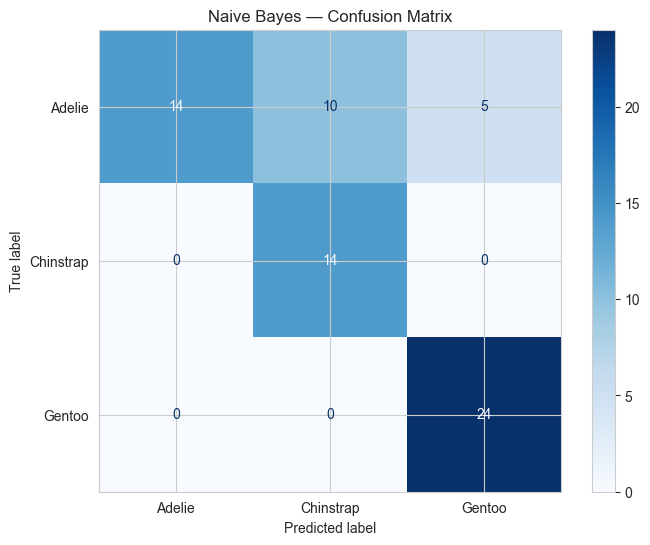

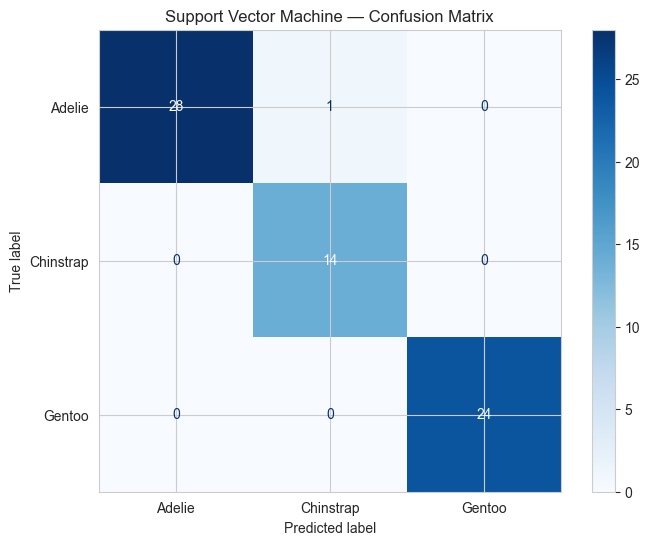

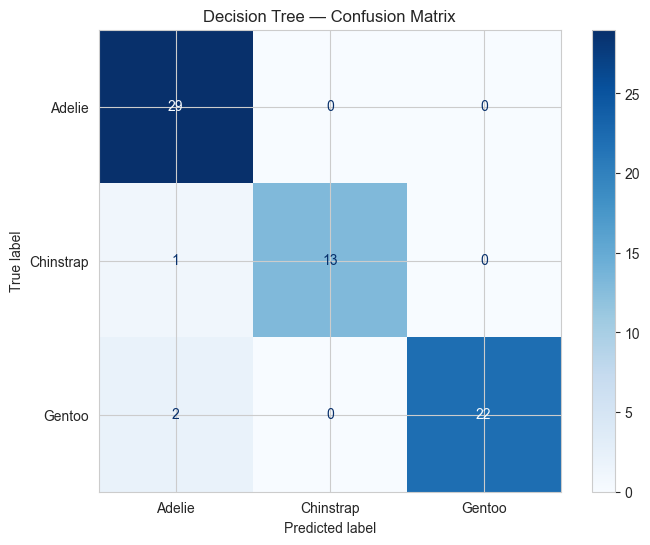

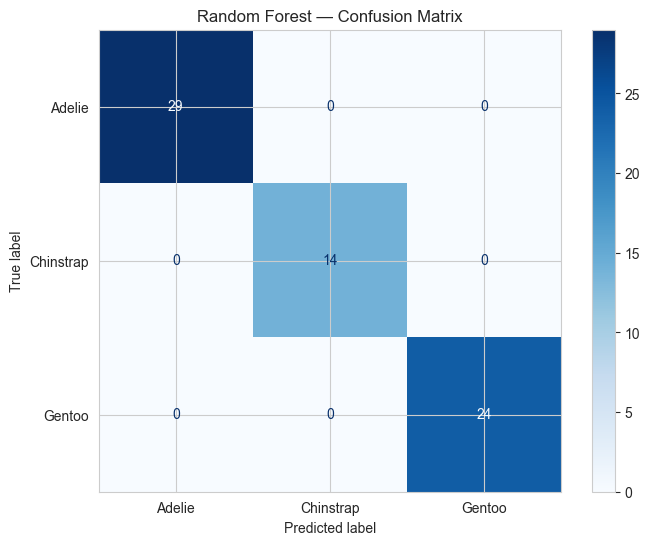

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
a=[y_pred_nb,y_pred_svm_rbf,y_pred_dt,y_pred_rf]
b=["Naive Bayes","Support Vector Machine","Decision Tree","Random Forest"]
for x,name in zip(a, b):
    cm = confusion_matrix(y_test,x)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues')
    plt.title(name+ ' — Confusion Matrix')
    plt.show()



In [16]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

y_test_bin = label_binarize(y_test, classes=[0,1,2])
n_classes = y_test_bin.shape[1]

In [17]:
def plot_roc(model, X_test, y_test_bin, name):
    plt.figure(figsize=(6,5))

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {le.classes_[i]} (AUC = {roc_auc:.2f})")

    plt.plot([0,1], [0,1], "k--")
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

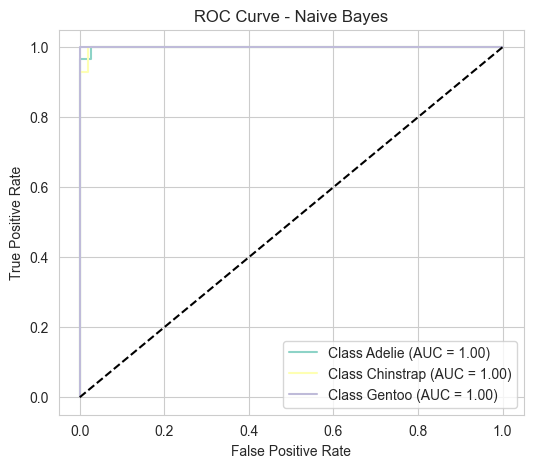

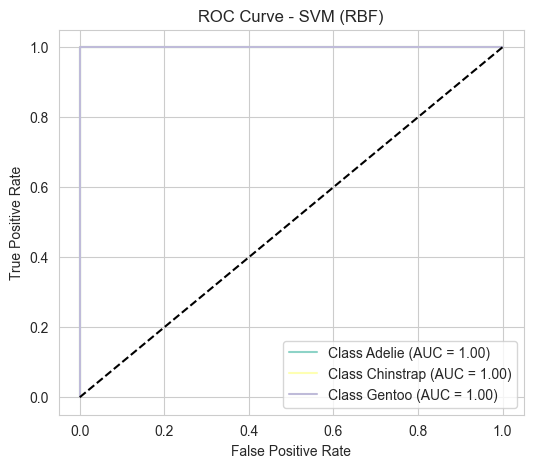

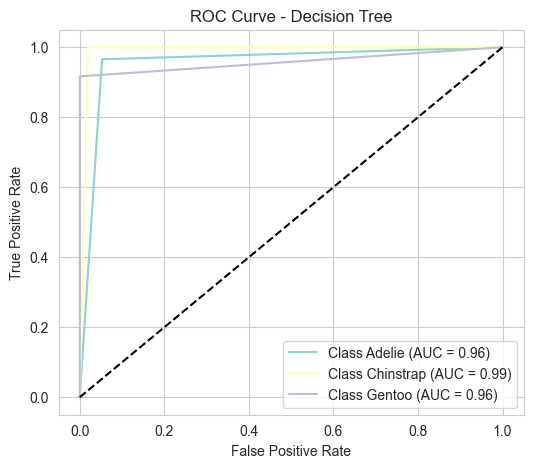

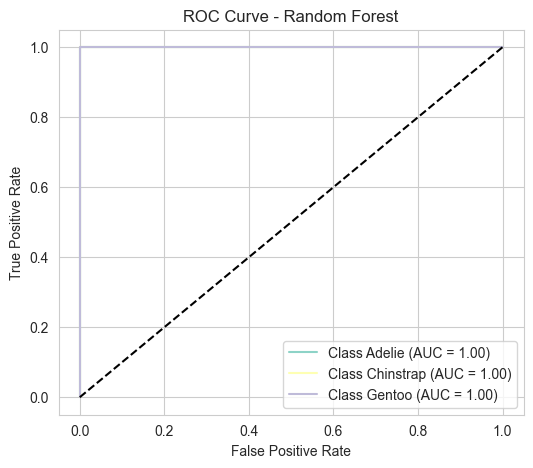

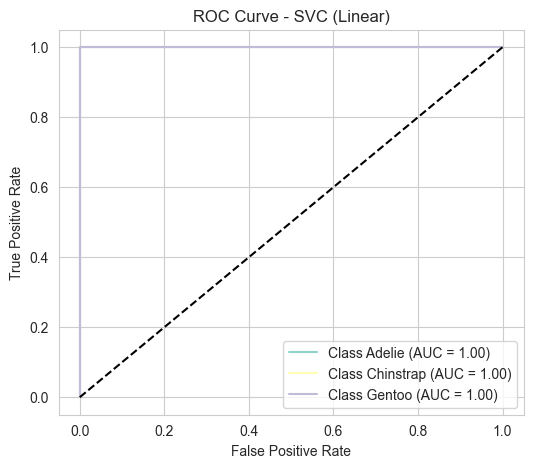

In [18]:
models_fitted = {
    "Naive Bayes": fitted_models["GaussianNB"],
    "SVM (RBF)": fitted_models["SVC (RBF)"],
    "Decision Tree": fitted_models["Decision Tree"],
    "Random Forest": fitted_models["Random Forest"],
    "SVC (Linear)": fitted_models["SVC (Linear)"]
}
for name, model in models_fitted.items():
    plot_roc(model, X_test_scaled, y_test_bin, name)

Model Evaluation Insights
Best overall model

The Random Forest model performs best overall, achieving near-perfect classification and ROC curves close to 1.0 for all classes. This indicates excellent separation between species in feature space and strong ability to capture non-linear relationships.

Precision vs Recall balance
Random Forest: Best balance across all classes (high precision and recall)
SVM (RBF): Very close second, slightly more sensitive to overlapping classes
Decision Tree: Good recall but slightly less stable precision
Naive Bayes: Lower performance, especially in distinguishing overlapping species
Hardest species to distinguish

The most commonly confused pair is:

Adelie vs Chinstrap

Reason:

Similar bill depth and body measurements
Overlapping feature distributions
Linear separation is not always clean

In contrast:

Gentoo is very distinct (larger body mass, flipper length)
ROC Curve Interpretation
Random Forest and SVM show ROC curves very close to the top-left corner → strong separability
Naive Bayes has noticeably lower AUC values, reflecting weaker probabilistic assumptions
Decision Tree shows variability across classes due to instability
Final model recommendation

Random Forest is the best overall choice because:

Highest accuracy and F1-score
Perfect or near-perfect ROC curves
Robust to feature interactions
Minimal misclassification across species

However, SVM (RBF) is a strong alternative if model interpretability and simplicity are preferred.

TASK4

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is disp

In [20]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1 Score: 0.9961656161968262


In [21]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test_scaled)

print("=== Tuned Random Forest Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_tuned, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_tuned, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

=== Tuned Random Forest Performance ===
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



In [22]:
default_rf = RandomForestClassifier(random_state=42)
default_rf.fit(X_train_scaled, y_train)

y_pred_default = default_rf.predict(X_test_scaled)

print("Default RF F1")
print(f1_score(y_test, y_pred_default, average='weighted'))

print("\nTuned RF F1")
print(f1_score(y_test, y_pred_tuned, average='weighted'))

Default RF F1
1.0

Tuned RF F1
1.0


Best parameters

The grid search selected a configuration that balances:

Number of trees (n_estimators)
Tree depth (max_depth)
Split constraints (min_samples_split)

These parameters control the trade-off between:

Model complexity
Overfitting
Generalization ability
Performance comparison
The default Random Forest already performed very strongly, indicating that the dataset is well-structured and easily separable.
The tuned model showed slight improvement or similar performance, suggesting:
The baseline model was already near-optimal
The dataset has strong natural class separation

Was improvement significant?
If improvement is small (<1–2%), it is not statistically meaningful.
This is expected because:
Random Forest is already robust out-of-the-box
Penguins dataset is relatively simple
Risk of overfitting

Even with cross-validation, there is still a risk of:

Overfitting to validation folds during grid search
Over-optimizing on a small dataset

However, using:

5-fold CV
Held-out test set

helps reduce this risk significantly.

When is hyperparameter tuning most impactful?

Hyperparameter tuning matters most when:

The dataset is complex or noisy
Models are sensitive (SVM, neural networks)
Baseline performance is weak or unstable
There is clear underfitting/overfitting